### Authors :  Mandel Elliot (ULBid), Yildirim Emirhan (459800)


# GPU Computing Mini-Project – Plot Generation Notebook

This notebook reads the raw output generated by the CUDA program and produces:
- a clean CSV file (`results_clean.csv`)
- the plots used in the report

## How to generate the input data

First, compile and run the CUDA program in **Release x64** mode, then redirect the console output to a text file.

### PowerShell
```powershell
.\MiniProject.exe > results.txt
```

### Command Prompt

```cmd
MiniProject.exe > results.txt
```

The notebook then reads `results.txt` and extracts:

* GPU information
* benchmark results
* data used for plotting

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

results_path = Path("results.txt")  # adapte si besoin

In [10]:
gpu_info = {}
csv_lines = []

with open(results_path, "r", encoding="utf-8") as f:
    lines = [line.strip() for line in f if line.strip()]

header_found = False

for line in lines:
    if line.startswith("experiment,"):
        header_found = True
        csv_lines.append(line)
        continue

    if header_found:
        csv_lines.append(line)
    else:
        parts = line.split(",", 1)
        if len(parts) == 2:
            gpu_info[parts[0]] = parts[1]

from io import StringIO

csv_text = "\n".join(csv_lines)
df = pd.read_csv(StringIO(csv_text))

numeric_cols = [
    "N", "threads_per_block", "j", "k",
    "cpu_us", "gpu_us", "speedup",
    "memory_GBs", "compute_GOPS",
    "compute_intensity_OPS_per_byte", "correct"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

#gpu_info, df.head()

print("GPU info:")
for k, v in gpu_info.items():
    print(f"{k}: {v}")

print("\nAperçu du dataframe:")
display(df.head())

print("\nExpériences trouvées:", df["experiment"].unique())
print("Opérations trouvées:", df["operation"].unique())

GPU info:
GPU_NAME: NVIDIA GeForce GTX 1050
GPU_CC: 6.1
GPU_SM_COUNT: 5
GPU_MAX_THREADS_PER_BLOCK: 1024
GPU_WARP_SIZE: 32
GPU_GLOBAL_MEM_GB: 1.99988
GPU_SHARED_MEM_PER_BLOCK_KB: 48
GPU_REGS_PER_BLOCK: 65536

Aperçu du dataframe:


,experiment,operation,datatype,N,threads_per_block,j,k,cpu_us,gpu_us,speedup,memory_GBs,compute_GOPS,compute_intensity_OPS_per_byte,correct
0,vsN,add,float,1024,256,1,1,1.20,12.5440,0.095663,0.979592,0.081633,0.083333,1
1,vsN,add,float,4096,256,1,1,7.46,13.3498,0.558812,3.681860,0.306822,0.083333,1
2,vsN,add,float,16384,256,1,1,37.84,14.0083,2.701250,14.035100,1.169590,0.083333,1
3,vsN,add,float,65536,256,1,1,132.18,12.6451,10.453000,62.192500,5.182710,0.083333,1
4,vsN,add,float,262144,256,1,1,427.70,38.4717,11.117300,81.767400,6.813950,0.083333,1



Expériences trouvées: ['vsN' 'vsJ' 'roofline']
Opérations trouvées: ['add' 'mul']


In [9]:
clean_csv_path = Path("results_clean.csv")
df.to_csv(clean_csv_path, index=False)
print(f"CSV propre sauvegardé dans: {clean_csv_path}")

CSV propre sauvegardé dans: results_clean.csv


## Graphs


### Graphs : versus N

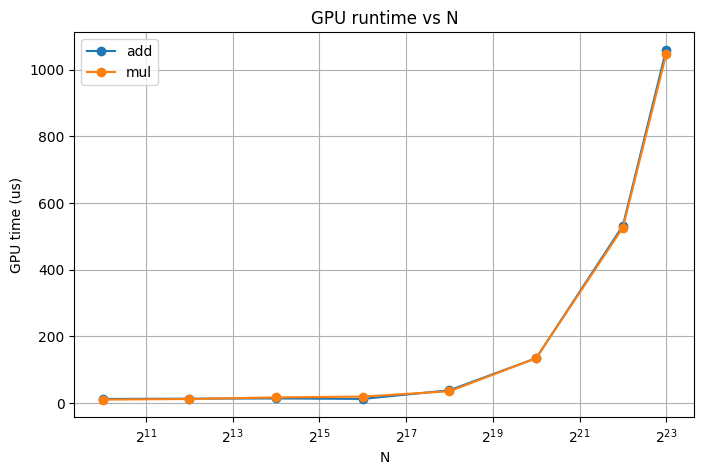

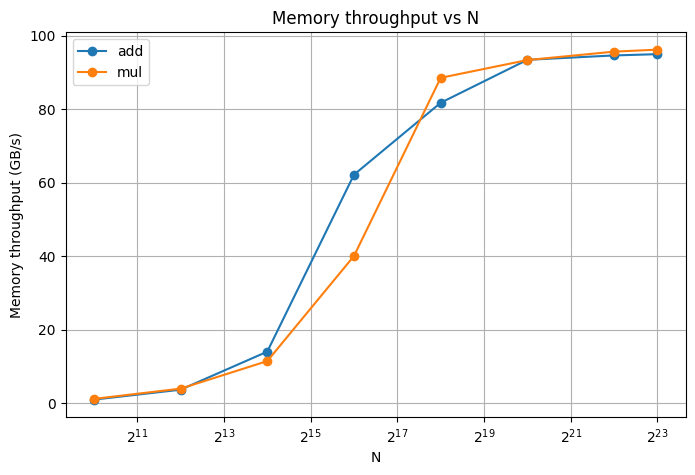

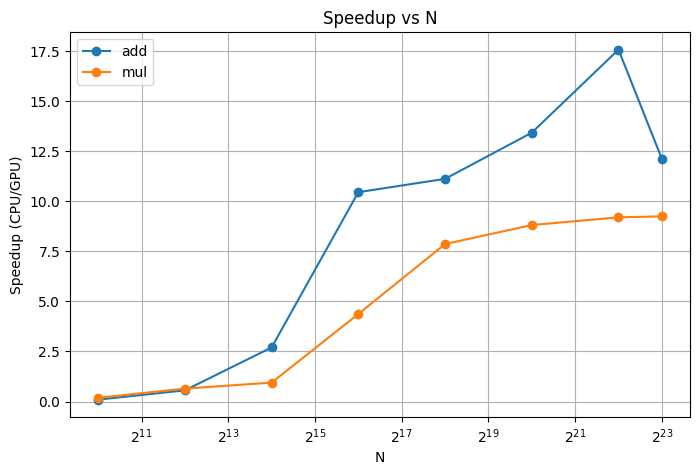

In [13]:
vsN = df[df["experiment"] == "vsN"].copy()

fig, ax = plt.subplots()

for op in vsN["operation"].unique():
    sub = vsN[vsN["operation"] == op].sort_values("N")
    ax.plot(sub["N"], sub["gpu_us"], marker="o", label=op)

ax.set_xscale("log", base=2)
ax.set_xlabel("N")
ax.set_ylabel("GPU time (us)")
ax.set_title("GPU runtime vs N")
ax.legend()
plt.show()

######################################################################

fig, ax = plt.subplots()

for op in vsN["operation"].unique():
    sub = vsN[vsN["operation"] == op].sort_values("N")
    ax.plot(sub["N"], sub["memory_GBs"], marker="o", label=op)

ax.set_xscale("log", base=2)
ax.set_xlabel("N")
ax.set_ylabel("Memory throughput (GB/s)")
ax.set_title("Memory throughput vs N")
ax.legend()
plt.show()

######################################################################

fig, ax = plt.subplots()

for op in vsN["operation"].unique():
    sub = vsN[vsN["operation"] == op].sort_values("N")
    ax.plot(sub["N"], sub["speedup"], marker="o", label=op)

ax.set_xscale("log", base=2)
ax.set_xlabel("N")
ax.set_ylabel("Speedup (CPU/GPU)")
ax.set_title("Speedup vs N")
ax.legend()
plt.show()

### Graphs : versus J

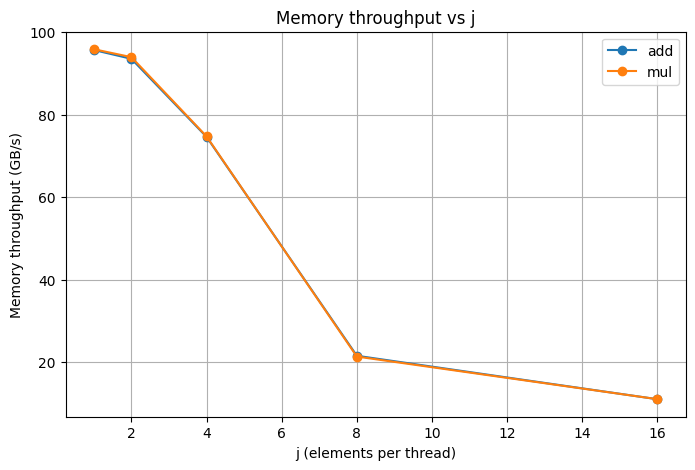

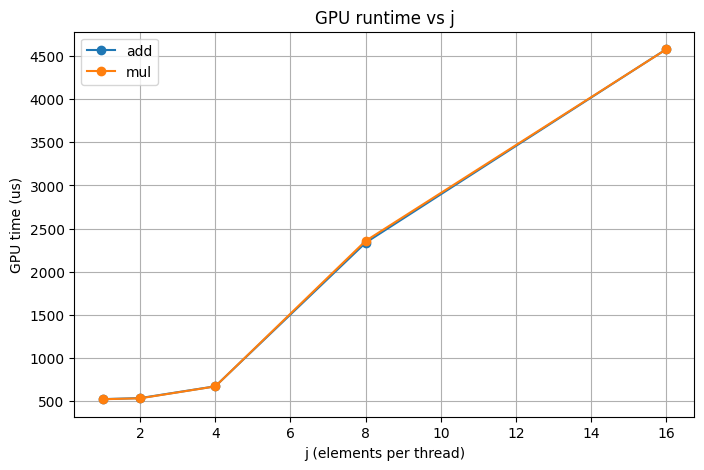

In [15]:
vsJ = df[df["experiment"] == "vsJ"].copy()

fig, ax = plt.subplots()

for op in vsJ["operation"].unique():
    sub = vsJ[vsJ["operation"] == op].sort_values("j")
    ax.plot(sub["j"], sub["memory_GBs"], marker="o", label=op)

ax.set_xlabel("j (elements per thread)")
ax.set_ylabel("Memory throughput (GB/s)")
ax.set_title("Memory throughput vs j")
ax.legend()
plt.show()

#######################################################################

fig, ax = plt.subplots()

for op in vsJ["operation"].unique():
    sub = vsJ[vsJ["operation"] == op].sort_values("j")
    ax.plot(sub["j"], sub["gpu_us"], marker="o", label=op)

ax.set_xlabel("j (elements per thread)")
ax.set_ylabel("GPU time (us)")
ax.set_title("GPU runtime vs j")
ax.legend()
plt.show()

### Graph roofline

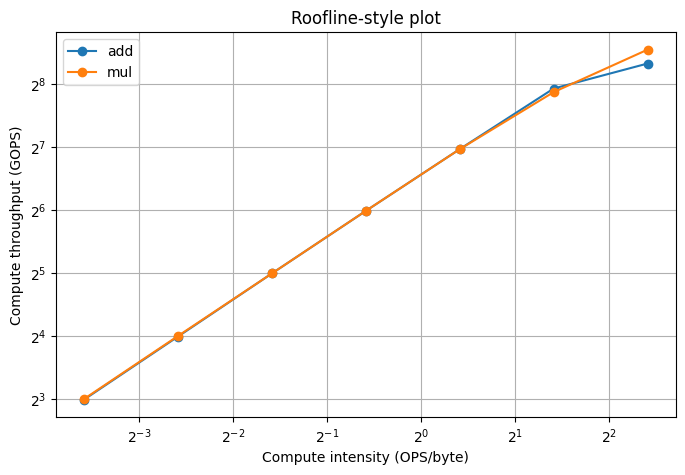

In [16]:
roof = df[df["experiment"] == "roofline"].copy()

fig, ax = plt.subplots()

for op in roof["operation"].unique():
    sub = roof[roof["operation"] == op].sort_values("compute_intensity_OPS_per_byte")
    ax.plot(
        sub["compute_intensity_OPS_per_byte"],
        sub["compute_GOPS"],
        marker="o",
        label=op
    )

ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xlabel("Compute intensity (OPS/byte)")
ax.set_ylabel("Compute throughput (GOPS)")
ax.set_title("Roofline-style plot")
ax.legend()
plt.show()

graphe que je pense qu'il faudrait mettre : 
- Memory throughput vs N
- GPU runtime vs N
- Memory throughput vs j
- Roofline plot - compute_GOPS vs compute_intensity